
# Практическая часть доклада: benchmark пайплайна обработки graph data в Python

**Тема:** рекомендации на user-item графе: от graph DB и in-memory представления до вычисления `recommendation_score` и сравнения подходов.

В ноутбуке сравниваются:

- **Graph DB:** Kùzu, встраиваемая graph database без отдельного сервера
- **chDB:** встраиваемый аналитический движок ClickHouse
- **Pandas**
- **Polars**
- **NumPy**

Чтобы ноутбук запускался в Google Colab без внешней инфраструктуры, данные генерируются синтетически, а graph DB поднимается локально внутри Python-процесса.

## Идея recommendation score

Работаем с bipartite-графом:

`User -> Item`

Для выбранного пользователя `u` рекомендуем товары/объекты, которые есть у похожих пользователей. Похожий пользователь здесь простой и объяснимый: тот, кто взаимодействовал хотя бы с одним item, который уже есть у `u`.

Score кандидата:

```text
score(u, candidate_item) = количество distinct other_users, которые пересекаются с User(u) по seen_item и имеют candidate_item
```

То есть чем у большего числа похожих пользователей встречается item, тем выше рекомендация.


In [1]:
!pip -q install -U polars chdb kuzu psutil pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.7/828.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.1/158.1 MB 7.9 MB/s eta 0:00:00


In [2]:
import gc
import os
import time
import math
import shutil
import tempfile
import tracemalloc
import importlib
from typing import Callable, Dict, Any, Optional, Tuple, List

import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt
from IPython.display import display

def optional_import(package_name: str):
    try:
        return importlib.import_module(package_name)
    except Exception as e:
        print(f"Can't be imported {package_name}: {e}")
        return None

pl = optional_import("polars")
chdb = optional_import("chdb")
kuzu = optional_import("kuzu")

PROCESS = psutil.Process(os.getpid())

QUICK_MODE = True
TOP_K = 10
REPEAT = 3
WARMUP = 1
TARGET_USER = 0
SEED = 42

if QUICK_MODE:
    BENCH_CONFIGS = [
        {"dataset": "small",  "n_users": 2_000,  "n_items": 2_000,  "n_edges": 80_000},
        {"dataset": "medium", "n_users": 8_000,  "n_items": 6_000,  "n_edges": 300_000},
    ]
else:
    BENCH_CONFIGS = [
        {"dataset": "small",  "n_users": 2_000,   "n_items": 2_000,   "n_edges": 80_000},
        {"dataset": "medium", "n_users": 10_000,  "n_items": 8_000,   "n_edges": 500_000},
        {"dataset": "large",  "n_users": 30_000,  "n_items": 20_000,  "n_edges": 1_500_000},
    ]

print("Libraries:")
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("polars", getattr(pl, "__version__", None))
print("chdb", getattr(chdb, "__version__", None))
print("kuzu", getattr(kuzu, "__version__", None))


Libraries:
pandas 2.2.2
numpy 2.0.2
polars 1.40.1
chdb 4.1.6
kuzu 0.11.3



## 1. Генерация синтетического user-item графа



In [3]:
def generate_interactions(
    n_users: int,
    n_items: int,
    n_edges: int,
    target_user: int = 0,
    target_degree: int = 50,
    seed: int = 42,
) -> pd.DataFrame:
    """Generates unique pairs (user_id, item_id)."""
    if n_edges > n_users * n_items:
        raise ValueError("n_edges can't be more than n_users * n_items for unique pairs")

    rng = np.random.default_rng(seed)
    target_degree = int(min(max(1, target_degree), n_items, n_edges))

    target_items = rng.choice(n_items, size=target_degree, replace=False).astype(np.int32)
    edges = pd.DataFrame({
        "user_id": np.full(target_degree, target_user, dtype=np.int32),
        "item_id": target_items,
    })

    while len(edges) < n_edges:
        remaining = n_edges - len(edges)
        batch_size = int(remaining * 1.35) + 1_000
        sample = pd.DataFrame({
            "user_id": rng.integers(0, n_users, size=batch_size, dtype=np.int32),
            "item_id": rng.integers(0, n_items, size=batch_size, dtype=np.int32),
        })
        edges = pd.concat([edges, sample], ignore_index=True)
        edges = edges.drop_duplicates(["user_id", "item_id"], keep="first")

    edges = edges.head(n_edges).sort_values(["user_id", "item_id"]).reset_index(drop=True)
    edges["user_id"] = edges["user_id"].astype(np.int32)
    edges["item_id"] = edges["item_id"].astype(np.int32)
    return edges


def dataset_stats(edges_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "metric": [
            "edges",
            "unique_users",
            "unique_items",
            "avg_degree_per_user",
            "pandas_memory_mb",
        ],
        "value": [
            len(edges_df),
            edges_df["user_id"].nunique(),
            edges_df["item_id"].nunique(),
            len(edges_df) / edges_df["user_id"].nunique(),
            edges_df.memory_usage(deep=True).sum() / 2**20,
        ],
    })

sample_edges = generate_interactions(100, 80, 1_000, seed=SEED)
display(sample_edges.head())
display(dataset_stats(sample_edges))


,user_id,item_id
0,0,2
1,0,3
2,0,4
3,0,5
4,0,6


,metric,value
0,edges,1000.000000
1,unique_users,100.000000
2,unique_items,80.000000
3,avg_degree_per_user,10.000000
4,pandas_memory_mb,0.007755



## 2. Вспомогательные функции: время, память, нормализация результатов

`tracemalloc` хорошо показывает Python-allocations, но не полностью видит память C/C++-движков. Поэтому дополнительно считаем изменение RSS процесса через `psutil`. RSS шумный, зато лучше отражает нативные движки вроде chDB/Kùzu/Polars.


In [4]:
def rss_mb() -> float:
    return PROCESS.memory_info().rss / 2**20


def pandas_memory_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(deep=True).sum() / 2**20


def polars_memory_mb(df) -> float:
    if df is None:
        return math.nan
    try:
        return df.estimated_size() / 2**20
    except Exception:
        return math.nan


def normalize_result(result: pd.DataFrame, k: int = TOP_K) -> pd.DataFrame:
    """Represent result as: item_id, score."""
    if result is None or len(result) == 0:
        return pd.DataFrame({"item_id": pd.Series(dtype="int32"), "score": pd.Series(dtype="int64")})

    df = result.copy()
    rename_map = {}
    for col in df.columns:
        low = str(col).lower()
        if low in {"cand.id", "item", "itemid", "item_id"}:
            rename_map[col] = "item_id"
        if low in {"count", "count(*)", "score"}:
            rename_map[col] = "score"
    df = df.rename(columns=rename_map)

    df = df[["item_id", "score"]]
    df["item_id"] = df["item_id"].astype(np.int32)
    df["score"] = df["score"].astype(np.int64)
    df = df.sort_values(["score", "item_id"], ascending=[False, True]).head(k).reset_index(drop=True)
    return df


def measure_call(
    func: Callable[[], pd.DataFrame],
    repeat: int = REPEAT,
    warmup: int = WARMUP,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """Measures time and memory of function. Returns last result + aggregated metrics."""
    for _ in range(warmup):
        _ = func()

    times_ms = []
    py_peaks_mb = []
    rss_deltas_mb = []
    last_result = None

    for _ in range(repeat):
        gc.collect()
        rss_before = rss_mb()
        tracemalloc.start()
        t0 = time.perf_counter()
        last_result = func()
        elapsed_ms = (time.perf_counter() - t0) * 1_000
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        rss_after = rss_mb()

        times_ms.append(elapsed_ms)
        py_peaks_mb.append(peak / 2**20)
        rss_deltas_mb.append(rss_after - rss_before)

    return last_result, {
        "time_ms_mean": float(np.mean(times_ms)),
        "time_ms_min": float(np.min(times_ms)),
        "py_peak_mb_mean": float(np.mean(py_peaks_mb)),
        "rss_delta_mb_mean": float(np.mean(rss_deltas_mb)),
    }


def timed_build(build_func: Callable[[], Any]) -> Tuple[Any, Dict[str, float]]:
    gc.collect()
    rss_before = rss_mb()
    tracemalloc.start()
    t0 = time.perf_counter()
    obj = build_func()
    elapsed_ms = (time.perf_counter() - t0) * 1_000
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after = rss_mb()
    return obj, {
        "time_ms": elapsed_ms,
        "py_peak_mb": peak / 2**20,
        "rss_delta_mb": rss_after - rss_before,
    }



## 3. Реализации recommendation score

Все реализации считают одно и то же:

1. берём items, уже виденные target user;
2. находим пользователей, у которых есть пересечение с target user;
3. считаем, у скольких distinct похожих пользователей встречается каждый candidate item;
4. исключаем уже виденные target user items;
5. сортируем по `score`.


In [8]:
def recommend_pandas(edges_df: pd.DataFrame, target_user: int, k: int = TOP_K) -> pd.DataFrame:
    target_items = edges_df.loc[edges_df["user_id"].eq(target_user), ["item_id"]].drop_duplicates()

    similar_users = (
        edges_df.merge(target_items, on="item_id", how="inner", sort=False)
        .loc[lambda x: x["user_id"].ne(target_user), ["user_id"]]
        .drop_duplicates()
    )

    candidates = edges_df.merge(similar_users, on="user_id", how="inner", sort=False)
    candidates = candidates.loc[~candidates["item_id"].isin(target_items["item_id"])]

    out = (
        candidates.groupby("item_id", sort=False)
        .size()
        .rename("score")
        .reset_index()
        .sort_values(["score", "item_id"], ascending=[False, True])
        .head(k)
        .reset_index(drop=True)
    )
    return out


def recommend_numpy(user_ids: np.ndarray, item_ids: np.ndarray, n_items: int, target_user: int, k: int = TOP_K) -> pd.DataFrame:
    target_items = np.unique(item_ids[user_ids == target_user])
    if len(target_items) == 0:
        return pd.DataFrame({"item_id": [], "score": []})

    mask_target_items = np.isin(item_ids, target_items)
    similar_users = np.unique(user_ids[mask_target_items & (user_ids != target_user)])
    if len(similar_users) == 0:
        return pd.DataFrame({"item_id": [], "score": []})

    mask_similar_users = np.isin(user_ids, similar_users)
    candidate_items = item_ids[mask_similar_users]
    candidate_items = candidate_items[~np.isin(candidate_items, target_items)]
    if len(candidate_items) == 0:
        return pd.DataFrame({"item_id": [], "score": []})

    scores = np.bincount(candidate_items, minlength=n_items)
    nonzero_items = np.flatnonzero(scores)
    order = np.lexsort((nonzero_items, -scores[nonzero_items]))
    top_items = nonzero_items[order][:k]

    return pd.DataFrame({
        "item_id": top_items.astype(np.int32),
        "score": scores[top_items].astype(np.int64),
    })


def recommend_polars(edges_pl, target_user: int, k: int = TOP_K) -> pd.DataFrame:
    target_items = (
        edges_pl
        .filter(pl.col("user_id") == target_user)
        .select("item_id")
        .unique()
    )

    similar_users = (
        edges_pl
        .join(target_items, on="item_id", how="inner")
        .filter(pl.col("user_id") != target_user)
        .select("user_id")
        .unique()
    )

    grouped = (
        edges_pl
        .join(similar_users, on="user_id", how="inner")
        .join(target_items, on="item_id", how="anti")
        .group_by("item_id")
        .len()
    )

    count_col = "len" if "len" in grouped.columns else "count"
    out = (
        grouped
        .rename({count_col: "score"})
        .sort(["score", "item_id"], descending=[True, False])
        .head(k)
        .to_pandas()
    )
    return out


def recommend_chdb(edges_df: pd.DataFrame, target_user: int, k: int = TOP_K) -> pd.DataFrame:
    global EDGES_DF_CHDB
    EDGES_DF_CHDB = edges_df

    sql = f"""
    SELECT
        e.item_id AS item_id,
        count() AS score
    FROM Python(EDGES_DF_CHDB) AS e
    INNER JOIN
    (
        SELECT DISTINCT user_id
        FROM Python(EDGES_DF_CHDB)
        WHERE item_id IN
        (
            SELECT item_id
            FROM Python(EDGES_DF_CHDB)
            WHERE user_id = {int(target_user)}
        )
        AND user_id != {int(target_user)}
    ) AS su USING (user_id)
    WHERE e.item_id NOT IN
    (
        SELECT item_id
        FROM Python(EDGES_DF_CHDB)
        WHERE user_id = {int(target_user)}
    )
    GROUP BY e.item_id
    ORDER BY score DESC, item_id ASC
    LIMIT {int(k)}
    """
    return chdb.query(sql, "DataFrame")


def build_kuzu_graph(edges_df: pd.DataFrame, n_users: int, n_items: int) -> Dict[str, Any]:
    tmp_root = tempfile.mkdtemp(prefix="kuzu_recsys_root_")
    db_path = os.path.join(tmp_root, "recsys.kz")

    db = kuzu.Database(db_path)
    conn = kuzu.Connection(db)

    conn.execute("CREATE NODE TABLE User(id INT64, PRIMARY KEY(id));")
    conn.execute("CREATE NODE TABLE Item(id INT64, PRIMARY KEY(id));")
    conn.execute("CREATE REL TABLE INTERACTS(FROM User TO Item);")

    users_df = pd.DataFrame({"id": np.arange(n_users, dtype=np.int64)})
    items_df = pd.DataFrame({"id": np.arange(n_items, dtype=np.int64)})
    rel_df = edges_df[["user_id", "item_id"]].astype(np.int64)

    conn.execute("COPY User FROM $df", {"df": users_df})
    conn.execute("COPY Item FROM $df", {"df": items_df})
    conn.execute("COPY INTERACTS FROM $df", {"df": rel_df})

    return {"db": db, "conn": conn, "tmp_root": tmp_root, "db_path": db_path}


def recommend_kuzu(kuzu_ctx: Dict[str, Any], edges_df: pd.DataFrame, target_user: int, k: int = TOP_K) -> pd.DataFrame:
    conn = kuzu_ctx["conn"]
    query = f"""
    MATCH (u:User)-[:INTERACTS]->(seen:Item)<-[:INTERACTS]-(other:User)-[:INTERACTS]->(cand:Item)
    WHERE u.id = {int(target_user)} AND other.id <> {int(target_user)}
    RETURN cand.id AS item_id, COUNT(DISTINCT other.id) AS score
    ORDER BY score DESC, item_id ASC
    """
    out = conn.execute(query).get_as_df()

    # Remove already seen target user items.
    target_items = edges_df.loc[edges_df["user_id"].eq(target_user), "item_id"].unique()
    out = out.loc[~out["item_id"].isin(target_items)]
    return normalize_result(out, k=k)


def cleanup_kuzu(kuzu_ctx: Optional[Dict[str, Any]]) -> None:
    if not kuzu_ctx:
        return

    tmp_root = kuzu_ctx.get("tmp_root") or kuzu_ctx.get("db_dir")

    try:
        del kuzu_ctx["conn"]
        del kuzu_ctx["db"]
    except Exception:
        pass

    gc.collect()

    if tmp_root:
        shutil.rmtree(tmp_root, ignore_errors=True)



## 4. Проверка корректности на маленьком графе

Перед benchmark важно убедиться, что все способы возвращают одинаковый top-K.


In [9]:
test_edges = generate_interactions(500, 400, 10_000, seed=SEED)
test_user_ids = test_edges["user_id"].to_numpy(np.int32, copy=False)
test_item_ids = test_edges["item_id"].to_numpy(np.int32, copy=False)

baseline = normalize_result(recommend_numpy(test_user_ids, test_item_ids, 400, TARGET_USER, TOP_K), TOP_K)
print("NumPy baseline")
display(baseline)

checks = []
checks.append(("pandas", normalize_result(recommend_pandas(test_edges, TARGET_USER, TOP_K), TOP_K)))

if pl is not None:
    checks.append(("polars", normalize_result(recommend_polars(pl.from_pandas(test_edges), TARGET_USER, TOP_K), TOP_K)))

if chdb is not None:
    checks.append(("chdb", normalize_result(recommend_chdb(test_edges, TARGET_USER, TOP_K), TOP_K)))

if kuzu is not None:
    ctx = build_kuzu_graph(test_edges, 500, 400)
    try:
        checks.append(("kuzu", normalize_result(recommend_kuzu(ctx, test_edges, TARGET_USER, TOP_K), TOP_K)))
    finally:
        cleanup_kuzu(ctx)

for name, result in checks:
    ok = result.equals(baseline)
    print(f"{name:>8}: {'OK' if ok else 'DIFF'}")
    if not ok:
        print("Result:")
        display(result)


NumPy baseline


,item_id,score
0,58,35
1,289,35
2,161,34
3,358,34
4,9,33
5,14,33
6,156,33
7,254,33
8,262,33
9,326,33


  pandas: OK
  polars: OK
    chdb: OK
    kuzu: OK



## 5. Запуск benchmark

В таблицах ниже:

- `load/build` = создание представления данных: DataFrame, ndarray, graph DB storage;
- `recommend` = вычисление recommendation score;
- `time_ms_min` удобнее брать для сравнения «лучшего стабильного» запуска;
- `time_ms_mean` показывает среднее по нескольким повторам;
- `py_peak_mb_mean` показывает Python allocations;
- `rss_delta_mb_mean` приблизительно отражает изменение памяти процесса, включая native libs.


In [10]:

def add_row(rows: list, dataset_cfg: dict, method: str, phase: str, status: str = "ok", **metrics):
    row = {
        "dataset": dataset_cfg["dataset"],
        "n_users": dataset_cfg["n_users"],
        "n_items": dataset_cfg["n_items"],
        "n_edges": dataset_cfg["n_edges"],
        "method": method,
        "phase": phase,
        "status": status,
    }
    row.update(metrics)
    rows.append(row)


def run_benchmarks(configs: List[dict]) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    rows = []
    top_examples = {}

    for cfg_i, cfg in enumerate(configs):
        print("=" * 80)
        print(f"Dataset: {cfg['dataset']} | users={cfg['n_users']:,} items={cfg['n_items']:,} edges={cfg['n_edges']:,}")

        edges_df = generate_interactions(
            cfg["n_users"],
            cfg["n_items"],
            cfg["n_edges"],
            target_user=TARGET_USER,
            seed=SEED + cfg_i,
        )
        display(dataset_stats(edges_df))

        # Pandas representation already exists after generation.
        add_row(
            rows, cfg, "pandas", "load/build",
            time_ms=0.0,
            py_peak_mb=0.0,
            rss_delta_mb=0.0,
            representation_memory_mb=pandas_memory_mb(edges_df),
            note="source dataframe after generation",
        )

        # NumPy representation.
        try:
            (np_repr, np_build_metrics) = timed_build(lambda: (
                edges_df["user_id"].to_numpy(np.int32, copy=True),
                edges_df["item_id"].to_numpy(np.int32, copy=True),
            ))
            user_ids, item_ids = np_repr
            add_row(
                rows, cfg, "numpy", "load/build",
                **np_build_metrics,
                representation_memory_mb=(user_ids.nbytes + item_ids.nbytes) / 2**20,
            )
        except Exception as e:
            user_ids, item_ids = None, None
            add_row(rows, cfg, "numpy", "load/build", status="error", error=repr(e))

        # Polars representation.
        edges_pl = None
        if pl is not None:
            try:
                edges_pl, pl_build_metrics = timed_build(lambda: pl.from_pandas(edges_df))
                add_row(
                    rows, cfg, "polars", "load/build",
                    **pl_build_metrics,
                    representation_memory_mb=polars_memory_mb(edges_pl),
                )
            except Exception as e:
                add_row(rows, cfg, "polars", "load/build", status="error", error=repr(e))
        else:
            add_row(rows, cfg, "polars", "load/build", status="skipped", error="polars import failed")

        # chDB does not need prebuild here: it queries Pandas DataFrame via Python table function.
        if chdb is not None:
            add_row(
                rows, cfg, "chdb", "load/build",
                time_ms=0.0,
                py_peak_mb=0.0,
                rss_delta_mb=0.0,
                representation_memory_mb=pandas_memory_mb(edges_df),
                note="queries pandas dataframe through Python() table function",
            )
        else:
            add_row(rows, cfg, "chdb", "load/build", status="skipped", error="chdb import failed")

        # Kùzu graph DB build.
        kuzu_ctx = None
        if kuzu is not None:
            try:
                kuzu_ctx, kuzu_build_metrics = timed_build(lambda: build_kuzu_graph(edges_df, cfg["n_users"], cfg["n_items"]))
                add_row(
                    rows, cfg, "kuzu_graph_db", "load/build",
                    **kuzu_build_metrics,
                    representation_memory_mb=math.nan,
                    note="embedded graph database build: nodes + relationships",
                )
            except Exception as e:
                add_row(rows, cfg, "kuzu_graph_db", "load/build", status="error", error=repr(e))
        else:
            add_row(rows, cfg, "kuzu_graph_db", "load/build", status="skipped", error="kuzu import failed")

        methods = []
        methods.append(("pandas", lambda: recommend_pandas(edges_df, TARGET_USER, TOP_K)))
        if user_ids is not None and item_ids is not None:
            methods.append(("numpy", lambda: recommend_numpy(user_ids, item_ids, cfg["n_items"], TARGET_USER, TOP_K)))
        if edges_pl is not None:
            methods.append(("polars", lambda: recommend_polars(edges_pl, TARGET_USER, TOP_K)))
        if chdb is not None:
            methods.append(("chdb", lambda: recommend_chdb(edges_df, TARGET_USER, TOP_K)))
        if kuzu_ctx is not None:
            methods.append(("kuzu_graph_db", lambda: recommend_kuzu(kuzu_ctx, edges_df, TARGET_USER, TOP_K)))

        baseline_result = None
        dataset_top_rows = []

        for method_name, func in methods:
            try:
                result, metrics = measure_call(func, repeat=REPEAT, warmup=WARMUP)
                result = normalize_result(result, TOP_K)

                if baseline_result is None and method_name == "numpy":
                    baseline_result = result

                add_row(rows, cfg, method_name, "recommend", **metrics, top_k=TOP_K)
                result_to_store = result.copy()
                result_to_store.insert(0, "method", method_name)
                dataset_top_rows.append(result_to_store)
                print(f"{method_name:>14}: {metrics['time_ms_min']:.2f} ms min")
            except Exception as e:
                add_row(rows, cfg, method_name, "recommend", status="error", error=repr(e))
                print(f"{method_name:>14}: ERROR {e}")

        if dataset_top_rows:
            top_examples[cfg["dataset"]] = pd.concat(dataset_top_rows, ignore_index=True)

        if baseline_result is not None and cfg["dataset"] in top_examples:
            print("Correctness check vs NumPy baseline:")
            for method_name in top_examples[cfg["dataset"]]["method"].unique():
                candidate = top_examples[cfg["dataset"]].query("method == @method_name")[["item_id", "score"]].reset_index(drop=True)
                print(f"{method_name:>14}: {'OK' if candidate.equals(baseline_result) else 'DIFF'}")

        cleanup_kuzu(kuzu_ctx)
        gc.collect()

    return pd.DataFrame(rows), top_examples

results_df, top_examples = run_benchmarks(BENCH_CONFIGS)


Dataset: small | users=2,000 items=2,000 edges=80,000


,metric,value
0,edges,80000.000000
1,unique_users,2000.000000
2,unique_items,2000.000000
3,avg_degree_per_user,40.000000
4,pandas_memory_mb,0.610477


        pandas: 34.63 ms min
         numpy: 4.37 ms min
        polars: 12.27 ms min
          chdb: 91.79 ms min
 kuzu_graph_db: 98.23 ms min
Correctness check vs NumPy baseline:
        pandas: OK
         numpy: OK
        polars: OK
          chdb: OK
 kuzu_graph_db: OK
Dataset: medium | users=8,000 items=6,000 edges=300,000


,metric,value
0,edges,300000.000000
1,unique_users,8000.000000
2,unique_items,6000.000000
3,avg_degree_per_user,37.500000
4,pandas_memory_mb,2.288944


        pandas: 48.71 ms min
         numpy: 8.95 ms min
        polars: 21.42 ms min
          chdb: 99.20 ms min
 kuzu_graph_db: 140.81 ms min
Correctness check vs NumPy baseline:
        pandas: OK
         numpy: OK
        polars: OK
          chdb: OK
 kuzu_graph_db: OK



## 6. Результаты

In [13]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [14]:

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

results_sorted = results_df.sort_values(["dataset", "phase", "time_ms_min"], na_position="last").reset_index(drop=True)
display(results_sorted)

results_path = "/content/drive/MyDrive/graph_pipeline_benchmark_results.csv"
results_sorted.to_csv(results_path, index=False)
print(f"Saved: {results_path}")


,dataset,n_users,n_items,n_edges,method,phase,status,time_ms,py_peak_mb,rss_delta_mb,representation_memory_mb,note,time_ms_mean,time_ms_min,py_peak_mb_mean,rss_delta_mb_mean,top_k
0,medium,8000,6000,300000,pandas,load/build,ok,0.000000,0.000000,0.000000,2.288944,source dataframe after generation,NaN,NaN,NaN,NaN,NaN
1,medium,8000,6000,300000,numpy,load/build,ok,1.475670,2.289149,0.000000,2.288818,NaN,NaN,NaN,NaN,NaN,NaN
2,medium,8000,6000,300000,polars,load/build,ok,0.754370,0.002274,0.000000,2.288818,NaN,NaN,NaN,NaN,NaN,NaN
3,medium,8000,6000,300000,chdb,load/build,ok,0.000000,0.000000,0.000000,2.288944,queries pandas dataframe through Python() tabl...,NaN,NaN,NaN,NaN,NaN
4,medium,8000,6000,300000,kuzu_graph_db,load/build,ok,517.873989,6.985825,58.234375,NaN,embedded graph database build: nodes + relatio...,NaN,NaN,NaN,NaN,NaN
5,medium,8000,6000,300000,numpy,recommend,ok,NaN,NaN,NaN,NaN,NaN,11.483173,8.946763,4.600420,0.000000,10.0
6,medium,8000,6000,300000,polars,recommend,ok,NaN,NaN,NaN,NaN,NaN,25.001020,21.418643,0.009814,0.522135,10.0
7,medium,8000,6000,300000,pandas,recommend,ok,NaN,NaN,NaN,NaN,NaN,49.964723,48.706383,9.383324,0.001302,10.0
8,medium,8000,6000,300000,chdb,recommend,ok,NaN,NaN,NaN,NaN,NaN,105.269390,99.197954,0.296375,3.170573,10.0
9,medium,8000,6000,300000,kuzu_graph_db,recommend,ok,NaN,NaN,NaN,NaN,NaN,145.514997,140.812937,0.461438,0.417969,10.0


Saved: /content/drive/MyDrive/graph_pipeline_benchmark_results.csv


In [15]:
# Top-K рекомендации по каждому датасету и методу.
for dataset_name, top_df in top_examples.items():
    print("=" * 80)
    print(f"Top recommendations: {dataset_name}")
    display(top_df)


Top recommendations: small


,method,item_id,score
0,pandas,1407,58
1,pandas,758,52
2,pandas,1925,52
3,pandas,363,51
4,pandas,1282,51
5,pandas,1454,49
6,pandas,1958,49
7,pandas,412,48
8,pandas,444,48
9,pandas,485,48


Top recommendations: medium


,method,item_id,score
0,pandas,4749,44
1,pandas,4831,43
2,pandas,5895,42
3,pandas,1909,41
4,pandas,2285,41
5,pandas,5678,41
6,pandas,607,40
7,pandas,1011,40
8,pandas,1241,40
9,pandas,1512,40



## 7. Графики для доклада

Сравним минимальное время вычисления recommendation score.

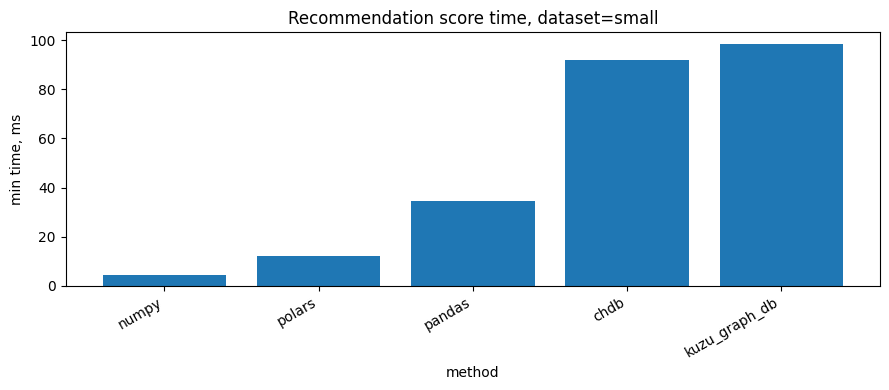

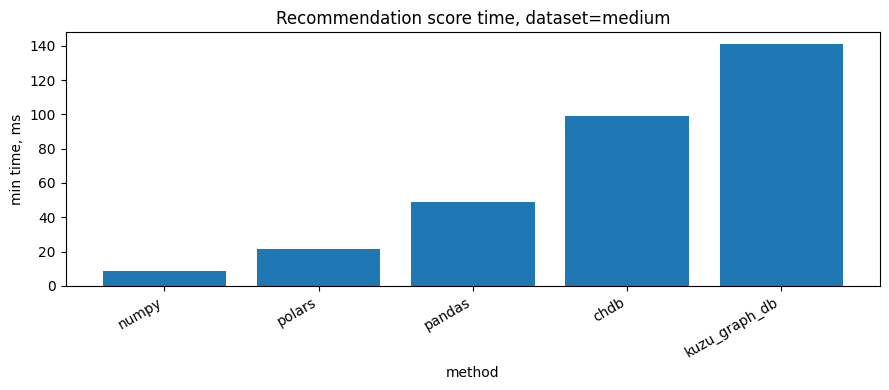

In [16]:
plot_df = results_df[(results_df["phase"] == "recommend") & (results_df["status"] == "ok")].copy()

for dataset_name in plot_df["dataset"].unique():
    sub = plot_df[plot_df["dataset"] == dataset_name].sort_values("time_ms_min")
    plt.figure(figsize=(9, 4))
    plt.bar(sub["method"], sub["time_ms_min"])
    plt.title(f"Recommendation score time, dataset={dataset_name}")
    plt.ylabel("min time, ms")
    plt.xlabel("method")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


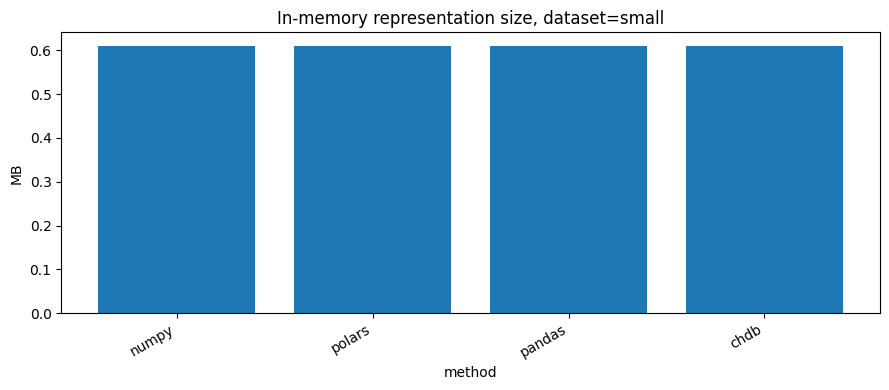

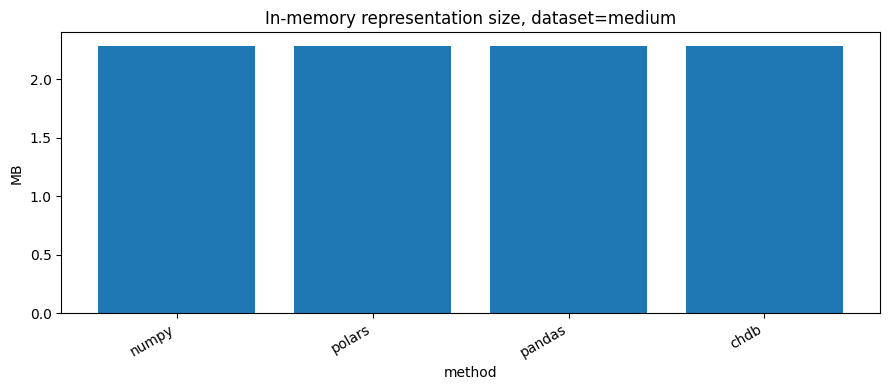

In [17]:
mem_df = results_df[(results_df["phase"] == "load/build") & (results_df["status"] == "ok")].copy()
mem_df = mem_df.dropna(subset=["representation_memory_mb"])

for dataset_name in mem_df["dataset"].unique():
    sub = mem_df[mem_df["dataset"] == dataset_name].sort_values("representation_memory_mb")
    plt.figure(figsize=(9, 4))
    plt.bar(sub["method"], sub["representation_memory_mb"])
    plt.title(f"In-memory representation size, dataset={dataset_name}")
    plt.ylabel("MB")
    plt.xlabel("method")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
